<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/tarefa_de_casa_aula2_diabetes_reg_logistica_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa Aula 1 — Análise Exploratória, Pré-Processamento e Feature Engineering
## Dataset: Diabetes

Fonte: https://archive.ics.uci.edu/dataset/34/diabetes

Sobre o dataset: Ele é composto por 70 arquivos (um por paciente).


**Problema escolhido:** para cada medição de glicemia registrada, prever se a leitura está **alterada** (fora da faixa considerada normal, <70 ou >180 mg/dL — hipoglicemia ou hiperglicemia) ou **normal** (entre 70 e 180 mg/dL). O target é `Glicemia_Alterada` (1 = alterada, 0 = normal), o que dá um problema binário.

# **Importação de Bibliotecas**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

pd.set_option('display.max_columns', 50)

# 0. Construção da Base (de log de eventos para tabela)

Os 70 arquivos estão na pasta `Diabetes-Data/`: Data, Hora, Código, Valor. Vamos ler todos e concatenar em um único DataFrame, guardando o número do paciente.

In [ ]:
!apt-get update -qq
!apt-get install -y ncompress
!uncompress diabetes-data.tar.Z

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  ncompress
0 upgraded, 1 newly installed, 0 to remove and 118 not upgraded.
Need to get 22.0 kB of archives.
After this operation, 58.4 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncompress amd64 4.2.4.6-5 [22.0 kB]
Fetched 22.0 kB in 0s (778 kB/s)
Selecting previously unselected package ncompress.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../ncompress_4.2.4.6-5_amd64.deb ...
Unpacking ncompress (4.2.4.6-5) ...
Setting up ncompress (4.2.4.6-5) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!tar -xvf diabetes-data.tar

Diabetes-Data/
Diabetes-Data/data-01
Diabetes-Data/data-02
Diabetes-Data/data-03
Diabetes-Data/data-04
Diabetes-Data/data-05
Diabetes-Data/data-06
Diabetes-Data/data-07
Diabetes-Data/data-08
Diabetes-Data/data-09
Diabetes-Data/data-10
Diabetes-Data/data-11
Diabetes-Data/data-12
Diabetes-Data/data-13
Diabetes-Data/data-14
Diabetes-Data/data-15
Diabetes-Data/data-16
Diabetes-Data/data-17
Diabetes-Data/data-18
Diabetes-Data/data-19
Diabetes-Data/data-20
Diabetes-Data/data-21
Diabetes-Data/data-22
Diabetes-Data/data-23
Diabetes-Data/data-24
Diabetes-Data/data-25
Diabetes-Data/data-26
Diabetes-Data/data-27
Diabetes-Data/data-28
Diabetes-Data/data-29
Diabetes-Data/data-30
Diabetes-Data/data-31
Diabetes-Data/data-32
Diabetes-Data/data-33
Diabetes-Data/data-34
Diabetes-Data/data-35
Diabetes-Data/data-36
Diabetes-Data/data-37
Diabetes-Data/data-38
Diabetes-Data/data-39
Diabetes-Data/data-40
Diabetes-Data/data-41
Diabetes-Data/data-42
Diabetes-Data/data-43
Diabetes-Data/data-44
Diabetes-Data/dat

In [ ]:
arquivos = sorted(glob.glob(os.path.join('Diabetes-Data', 'data-*')))
print(f'Arquivos de pacientes encontrados: {len(arquivos)}')

frames = []
for f in arquivos:
    paciente_id = os.path.basename(f).replace('data-', '')
    tmp = pd.read_csv(f, sep='\t', header=None, names=['Date','Time','Code','Value'], dtype=str)
    tmp['PatientID'] = paciente_id
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)
df.head()

Arquivos de pacientes encontrados: 70


,Date,Time,Code,Value,PatientID
0,04-21-1991,9:09,58,100,01
1,04-21-1991,9:09,33,009,01
2,04-21-1991,9:09,34,013,01
3,04-21-1991,17:08,62,119,01
4,04-21-1991,17:08,33,007,01


In [ ]:
df.tail()

,Date,Time,Code,Value,PatientID
29325,05-09-1989,08:00,33,001,70
29326,05-09-1989,08:00,34,007,70
29327,05-10-1989,08:00,34,007,70
29328,05-11-1989,08:00,34,007,70
29329,05-12-1989,08:00,34,007,70


# I. Análise Exploratória Geral

1. Quantas linhas e colunas tem o dataset?
2. Qual a porcentagem de nulos?
3. Qual o tipo de cada coluna?
4. Existem colunas que podemos remover?
5. Os tipos de coluna estão adequados para os tipos de variáveis?
6. Temos dados duplicados?
7. Qual a média, desvio padrão e amplitude das colunas numéricas?

### 1. Quantas linhas e colunas tem o dataset?

In [ ]:
print(f'O dataset tem {df.shape[0]} linhas')
print(f'O dataset tem {df.shape[1]} colunas')
df.info()

O dataset tem 29330 linhas
O dataset tem 5 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29330 entries, 0 to 29329
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       29297 non-null  object
 1   Time       29330 non-null  object
 2   Code       29330 non-null  object
 3   Value      29297 non-null  object
 4   PatientID  29330 non-null  object
dtypes: object(5)
memory usage: 1.1+ MB


### 2. Qual a porcentagem de nulos?

In [ ]:
df_nulos = (df.isnull().sum()/df.shape[0]).sort_values(ascending=False)*100
df_nulos

,0
Date,0.112513
Value,0.112513
Time,0.000000
Code,0.000000
PatientID,0.000000


### 3. Qual o tipo de cada coluna?

In [ ]:
df.dtypes

,0
Date,object
Time,object
Code,object
Value,object
PatientID,object


### 4. Existem colunas que podemos remover?

Não vamos remover colunas ainda, mas o campo `Code` precisa ser decodificado: cada número representa um tipo de evento diferente (dose de insulina, medição de glicemia em momentos distintos do dia, refeição, exercício, sintoma de hipoglicemia etc.), conforme o dicionário de códigos do dataset (`Data-Codes`).

In [ ]:
codigo_map = {
    33: 'Dose de insulina regular',
    34: 'Dose de insulina NPH',
    35: 'Dose de insulina UltraLente',
    48: 'Glicemia (não especificada)',
    57: 'Glicemia (não especificada)',
    58: 'Glicemia pré-café',
    59: 'Glicemia pós-café',
    60: 'Glicemia pré-almoço',
    61: 'Glicemia pós-almoço',
    62: 'Glicemia pré-jantar',
    63: 'Glicemia pós-jantar',
    64: 'Glicemia pré-lanche',
    65: 'Sintomas de hipoglicemia',
    66: 'Refeição típica',
    67: 'Refeição maior que o usual',
    68: 'Refeição menor que o usual',
    69: 'Exercício típico',
    70: 'Exercício maior que o usual',
    71: 'Exercício menor que o usual',
    72: 'Evento especial não especificado',
}

df['Code'] = pd.to_numeric(df['Code'], errors='coerce')
df['Code'].value_counts(dropna=False).sort_index()

,count
Code,
0,33
4,1
33,9518
34,3830
35,1053
36,1
48,1883
56,119
57,990


Aparecem códigos não documentados no dicionário oficial (`0`, `4`, `36`, `56`) — provavelmente erros de digitação/gravação do equipamento original. Como não sabemos o que representam com segurança, vamos removê-los por serem poucas linhas

In [ ]:
linhas_antes = df.shape[0]
df = df[df['Code'].isin(codigo_map.keys())]
print(f'Linhas removidas por código não documentado: {linhas_antes - df.shape[0]}')

df['Evento'] = df['Code'].map(codigo_map)
df['Evento'].value_counts()

Linhas removidas por código não documentado: 154


,count
Evento,
Dose de insulina regular,9518
Dose de insulina NPH,3830
Glicemia pré-café,3518
Glicemia pré-jantar,3160
Glicemia (não especificada),2873
Glicemia pré-almoço,2771
Dose de insulina UltraLente,1053
Glicemia pré-lanche,904
Sintomas de hipoglicemia,331


### 5. Os tipos de coluna estão adequados para os tipos de variáveis?

`Date` + `Time` precisam virar um único campo `datetime`. Vamos testar a conversão e ver se aparecem problemas.

In [ ]:
df['DataHora'] = pd.to_datetime(df['Date'] + ' ' + df['Time'].str.strip(), format='%m-%d-%Y %H:%M', errors='coerce')
print('Registros com data/hora inválida (viraram NaT):', df['DataHora'].isna().sum())
df[df['DataHora'].isna()]

Registros com data/hora inválida (viraram NaT): 45


,Date,Time,Code,Value,PatientID,Evento,DataHora
6505,06-31-1991,07:50,58,149,20,Glicemia pré-café,NaT
6506,06-31-1991,07:50,33,004,20,Dose de insulina regular,NaT
6507,06-31-1991,07:50,34,024,20,Dose de insulina NPH,NaT
6508,06-31-1991,13:30,60,162,20,Glicemia pré-almoço,NaT
6509,06-31-1991,13:30,33,005,20,Dose de insulina regular,NaT
6510,06-31-1991,19:45,62,213,20,Glicemia pré-jantar,NaT
6511,06-31-1991,19:45,33,011,20,Dose de insulina regular,NaT
9961,NaN,138,33,3A,27,Dose de insulina regular,NaT
9963,NaN,006,33,21,27,Dose de insulina regular,NaT
9965,NaN,016,33,22,27,Dose de insulina regular,NaT


São 12 linhas com datas ou horários impossíveis (ex: `06-31-1991`, junho não tem dia 31 ou horário `188:00`), claramente erro de digitação nos registros originais em papel. Como são poucas e não temos como saber qual seria o valor correto, vamos removê-las.

### 6. Temos dados duplicados?

In [ ]:
print('Duplicados completos:', df.duplicated().sum())
#print('Duplicados por Paciente + DataHora + Código:', df.duplicated(subset=['PatientID','DataHora','Code']).sum())

Duplicados completos: 23


In [ ]:
linhas_antes = df.shape[0]
df = df.drop_duplicates()
print(f'Duplicados completos removidos: {linhas_antes - df.shape[0]}')
#df.info()

Duplicados completos removidos: 23


Havia 7 linhas duplicadas de forma completa e foram removidas.

### 7. Qual a média, desvio padrão e amplitude das colunas numéricas?

In [ ]:
df['Value_numerico'] = pd.to_numeric(df['Value'], errors='coerce')
df['Value_numerico'].describe()

,Value_numerico
count,29134.000000
mean,79.138515
std,93.448207
min,0.000000
25%,6.000000
50%,22.000000
75%,141.000000
max,501.000000


O `Value` mistura grandezas completamente diferentes na mesma coluna (dose de insulina em unidades, glicemia em mg/dL, contadores de evento), então essa estatística agregada não tem muito significado sozinha — ela só faz sentido quando olhamos `Value` separado por tipo de evento (`Code`/`Evento`).

# II. Análise Univariada

### Quais eventos são mais registrados?

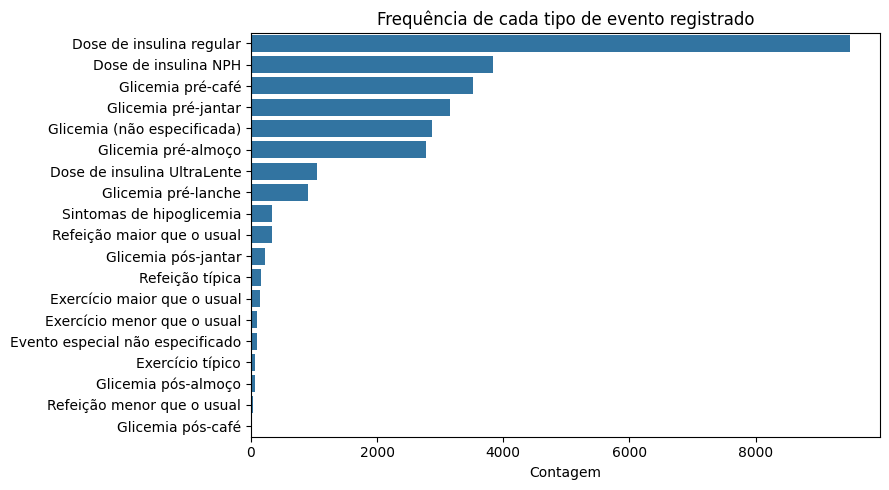

In [ ]:
plt.figure(figsize=(9,5))
ordem = df['Evento'].value_counts().index
sns.countplot(data=df, y='Evento', order=ordem)
plt.title('Frequência de cada tipo de evento registrado')
plt.xlabel('Contagem')
plt.ylabel('')
plt.tight_layout()
plt.show()

A maioria dos registros é dose de insulina regular e medições de glicemia pré-café/pré-jantar esperado, já que são os momentos de maior rotina de monitoramento.

### Quantos registros existem por paciente?

In [ ]:
registros_paciente = df.groupby('PatientID').size()
registros_paciente.describe()

,0
count,70.000000
mean,416.471429
std,303.420200
min,49.000000
25%,288.250000
50%,299.500000
75%,447.500000
max,1327.000000


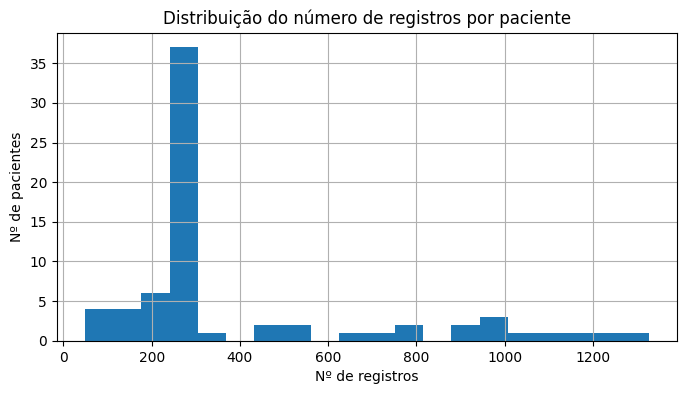

In [ ]:
plt.figure(figsize=(8,4))
registros_paciente.hist(bins=20)
plt.title('Distribuição do número de registros por paciente')
plt.xlabel('Nº de registros')
plt.ylabel('Nº de pacientes')
plt.show()

Há bastante variação: pacientes com pouco mais de 30 registros e outros com mais de 600. Isso é um sinal de que a quantidade de dados por paciente é bem desigual.

### Valores de glicemia (Value) para os códigos de medição de glicemia

In [ ]:
codigos_glicemia = [48, 57, 58, 59, 60, 61, 62, 63, 64]
gl_bruto = df[df['Code'].isin(codigos_glicemia)].copy()
print('Registros de medição de glicemia:', gl_bruto.shape[0])

mask_texto = gl_bruto['Value'].astype(str).str.contains('[A-Za-z]', regex=True)
print('Valores não numéricos:', mask_texto.sum())
gl_bruto.loc[mask_texto, 'Value'].value_counts()

Registros de medição de glicemia: 13531
Valores não numéricos: 7


,count
Value,
0Hi,6
0Lo,1


Os valores `0Hi` e `0Lo` são leituras em que o glicosímetro estourou a faixa de medição (glicemia extremamente alta ou extremamente baixa) e o aparelho grava um código de texto em vez do número. Isso já é um insight relevante: não podemos simplesmente descartar ou converter direto para número o `Hi`/`Lo` carrega informação (justamente as leituras mais extremas, que mais nos interessam para o problema de glicemia alterada). Vamos tratar isso explicitamente ao construir a variável de glicemia limpa.

# III. Tratamento e Construção da Variável-Alvo (Glicemia)

Isolar os registros de medição, tratar os valores em texto e só então construir o alvo.

In [ ]:
def parse_valor_glicemia(v):
    v = str(v).strip()
    if 'Hi' in v:
        return 400.0  # acima da faixa do medidor -> hiperglicemia extrema
    if 'Lo' in v:
        return 40.0   # abaixo da faixa do medidor -> hipoglicemia extrema
    try:
        return float(v)
    except ValueError:
        return np.nan

gl = df[df['Code'].isin(codigos_glicemia)].copy()
gl['Glicemia_mgdl'] = gl['Value'].apply(parse_valor_glicemia)
print('Nulos após conversão:', gl['Glicemia_mgdl'].isna().sum())
gl[gl['Glicemia_mgdl'].isna()]

Nulos após conversão: 1


,Date,Time,Code,Value,PatientID,Evento,DataHora,Value_numerico,Glicemia_mgdl
16466,11-06-1989,11:00,57,0'',40,Glicemia (não especificada),1989-11-06 11:00:00,NaN,NaN


Uma única linha tem valor corrompido (`0''`, sem sentido numérico), vamos descartá-la. Também vamos remover uma leitura de `0` mg/dL, fisiologicamente incompatível com um paciente vivo registrando seus próprios dados; é erro de digitação, não hipoglicemia real.

In [ ]:
linhas_antes = gl.shape[0]
gl = gl.dropna(subset=['Glicemia_mgdl'])
gl = gl[gl['Glicemia_mgdl'] > 0]
print(f'Linhas removidas por valor de glicemia inválido: {linhas_antes - gl.shape[0]}')
print('Shape final da base de glicemia:', gl.shape)
gl['Glicemia_mgdl'].describe()

Linhas removidas por valor de glicemia inválido: 2
Shape final da base de glicemia: (13529, 9)


,Glicemia_mgdl
count,13529.000000
mean,160.362185
std,80.294945
min,15.000000
25%,97.000000
50%,149.000000
75%,210.000000
max,501.000000


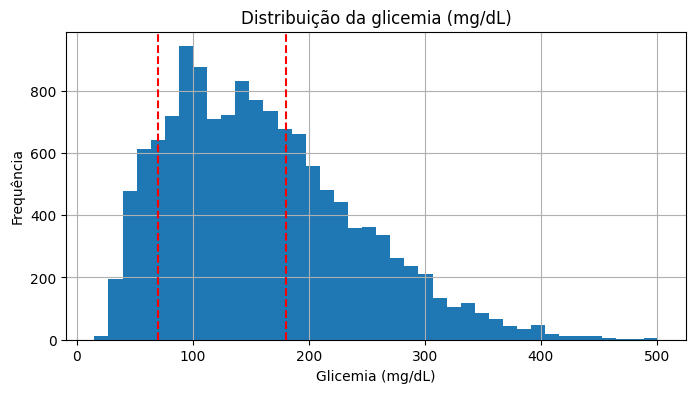

In [ ]:
plt.figure(figsize=(8,4))
gl['Glicemia_mgdl'].hist(bins=40)
plt.title('Distribuição da glicemia (mg/dL)')
plt.xlabel('Glicemia (mg/dL)')
plt.ylabel('Frequência')
plt.axvline(70, color='red', linestyle='--')
plt.axvline(180, color='red', linestyle='--')
plt.show()

### Construindo o alvo: `Glicemia_Alterada`

Faixa de referência usada: **normal = 70–180 mg/dL** (faixa amplamente usada em estudos de monitoramento de glicemia capilar; fora dela consideramos hipoglicemia ou hiperglicemia).

In [ ]:
gl['Glicemia_Alterada'] = ((gl['Glicemia_mgdl'] < 70) | (gl['Glicemia_mgdl'] > 180)).astype(int)

def faixa(v):
    if v < 70:
        return 'Hipoglicemia'
    if v > 180:
        return 'Hiperglicemia'
    return 'Normal'

gl['Faixa_Glicemia'] = gl['Glicemia_mgdl'].apply(faixa)
gl[['Glicemia_mgdl','Faixa_Glicemia','Glicemia_Alterada']].head()

,Glicemia_mgdl,Faixa_Glicemia,Glicemia_Alterada
0,100.0,Normal,0
3,119.0,Normal,0
5,123.0,Normal,0
6,216.0,Hiperglicemia,1
10,211.0,Hiperglicemia,1


### A target para o problema está desbalanceada?

Glicemia_Alterada
0    52.287678
1    47.712322
Name: proportion, dtype: float64


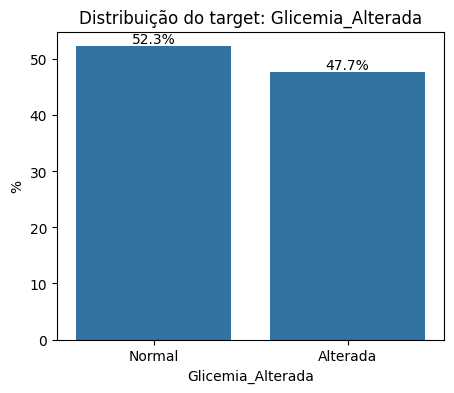

In [ ]:
target_dist = gl['Glicemia_Alterada'].value_counts(normalize=True)*100
print(target_dist)

plt.figure(figsize=(5,4))
ax = sns.barplot(x=target_dist.index.map({0:'Normal', 1:'Alterada'}), y=target_dist.values)
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', (barra.get_x()+barra.get_width()/2, altura), ha='center', va='bottom')
plt.title('Distribuição do target: Glicemia_Alterada')
plt.ylabel('%')
plt.show()

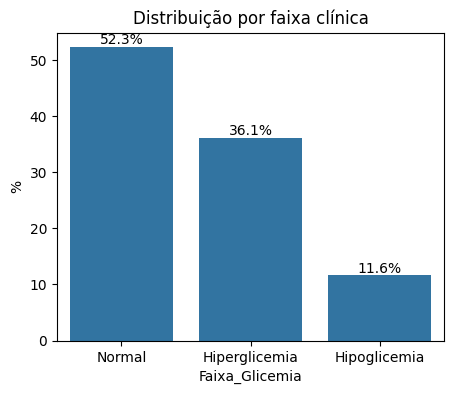

In [ ]:
plt.figure(figsize=(5,4))
faixa_dist = gl['Faixa_Glicemia'].value_counts(normalize=True)*100
ax = sns.barplot(x=faixa_dist.index, y=faixa_dist.values, order=['Normal','Hiperglicemia','Hipoglicemia'])
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', (barra.get_x()+barra.get_width()/2, altura), ha='center', va='bottom')
plt.title('Distribuição por faixa clínica')
plt.ylabel('%')
plt.show()

**Resposta:** o target ficou próximo de **52% Normal / 48% Alterada**. Olhando por faixa clínica, a maior parte dos casos "alterados" é hiperglicemia (36%) e uma minoria é hipoglicemia (12%), o que já é um insight clínico interessante: o risco de glicemia alta é bem mais frequente que o de glicemia baixa nesses pacientes.

# IV. Análise Bivariada

* O momento da medição (antes/depois da refeição) influencia a taxa de glicemia alterada?
* O período do dia influencia?
* Refeição ou exercício fora do padrão no dia influenciam?
* A dose de insulina do dia é diferente entre quem teve glicemia alterada e quem não teve?
* Existe muita variação entre pacientes?

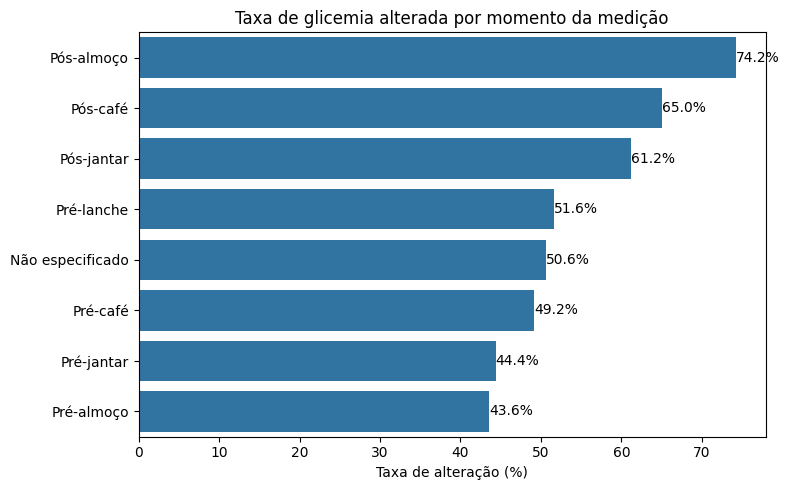

In [ ]:
momento_map = {
    48: 'Não especificado', 57: 'Não especificado',
    58: 'Pré-café', 59: 'Pós-café',
    60: 'Pré-almoço', 61: 'Pós-almoço',
    62: 'Pré-jantar', 63: 'Pós-jantar',
    64: 'Pré-lanche',
}
gl['Momento_Medicao'] = gl['Code'].map(momento_map)

taxa_momento = (gl.groupby('Momento_Medicao')['Glicemia_Alterada'].mean()*100).sort_values(ascending=False).reset_index(name='Taxa_Alterada')

plt.figure(figsize=(8,5))
ax = sns.barplot(data=taxa_momento, y='Momento_Medicao', x='Taxa_Alterada', order=taxa_momento['Momento_Medicao'])
for barra in ax.patches:
    largura = barra.get_width()
    ax.annotate(f'{largura:.1f}%', (largura, barra.get_y()+barra.get_height()/2), ha='left', va='center')
plt.title('Taxa de glicemia alterada por momento da medição')
plt.xlabel('Taxa de alteração (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

As leituras pós-refeição têm taxa de alteração muito maior que as pré-refeição (pós-almoço 74% vs pré-almoço 44%, por exemplo), faz sentido fisiológico (glicemia sobe depois de comer) e é um insight relevante: o momento da medição em relação à refeição é uma variável muito informativa para o problema.

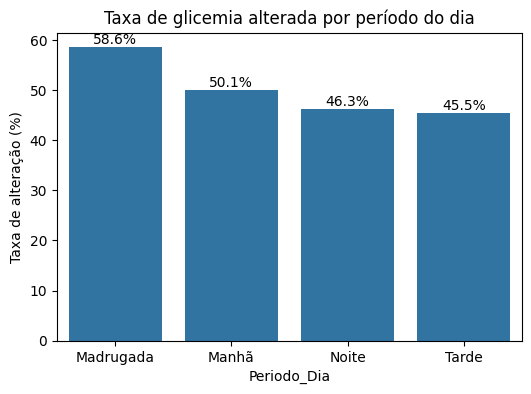

In [ ]:
df['Hora'] = df['DataHora'].dt.hour
gl['Hora'] = gl['DataHora'].dt.hour

def periodo(h):
    if 0 <= h < 6:
        return 'Madrugada'
    if 6 <= h < 12:
        return 'Manhã'
    if 12 <= h < 18:
        return 'Tarde'
    return 'Noite'

gl['Periodo_Dia'] = gl['Hora'].apply(periodo)

taxa_periodo = (gl.groupby('Periodo_Dia')['Glicemia_Alterada'].mean()*100).sort_values(ascending=False).reset_index(name='Taxa_Alterada')

plt.figure(figsize=(6,4))
ax = sns.barplot(data=taxa_periodo, x='Periodo_Dia', y='Taxa_Alterada', order=taxa_periodo['Periodo_Dia'])
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', (barra.get_x()+barra.get_width()/2, altura), ha='center', va='bottom')
plt.title('Taxa de glicemia alterada por período do dia')
plt.ylabel('Taxa de alteração (%)')
plt.show()

A madrugada tem a maior taxa de alteração (~59%) pode refletir tanto hipoglicemias noturnas quanto o efeito conhecido como 'fenômeno do amanhecer' (elevação de glicemia nas primeiras horas da manhã).

In [ ]:
gl['DiaSemana'] = gl['DataHora'].dt.day_name()
taxa_dia = (gl.groupby('DiaSemana')['Glicemia_Alterada'].mean()*100).sort_values(ascending=False)
taxa_dia

,Glicemia_Alterada
DiaSemana,
Saturday,52.380952
Sunday,49.139785
Thursday,47.850563
Friday,46.705324
Tuesday,46.646185
Monday,46.169056
Wednesday,45.572139


Por dia da semana a taxa fica bem próxima entre 45% e 52% em todos os dias, não parece ser uma variável relevante para diferenciar o target, diferente do momento da refeição e do período do dia.

In [ ]:
tmp = df[df["Code"].isin([33, 34, 35])].copy()
tmp["Value_num"] = pd.to_numeric(tmp["Value"], errors="coerce")
tmp["Date_dt"] = pd.to_datetime(tmp["Date"], errors="coerce")
tmp[tmp["Date_dt"].isna()][["Date"]].drop_duplicates()

,Date
6506,06-31-1991
9961,NaN


#### Bloco abaixo que deixou de funcionar após correção lá em cima

In [ ]:
#insulina_diaria = (
#    df[df['Code'].isin([33,34,35])]
#    .assign(Value_num=lambda x: pd.to_numeric(x['Value'], errors='coerce'))
#    .assign(Date=lambda x: pd.to_datetime(x['Date'], format='%m-%d-%Y').dt.date.astype(str))
#    .groupby(['PatientID','Date'])['Value_num'].sum()
#    .reset_index(name='Insulina_Dose_Dia')
#)
#gl['Date'] = gl['DataHora'].dt.date.astype(str)
#
#gl = gl.merge(insulina_diaria, on=['PatientID','Date'], how='left')
#gl['Insulina_Dose_Dia'] = gl['Insulina_Dose_Dia'].fillna(0)
#
#gl.groupby('Glicemia_Alterada')['Insulina_Dose_Dia'].mean()

#### Bloco refeito abaixo

In [ ]:
tmp = df[df["Code"].isin([33, 34, 35])].copy()
tmp["Value_num"] = pd.to_numeric(tmp["Value"], errors="coerce")
tmp["Date_dt"] = pd.to_datetime(tmp["Date"], errors="coerce")

tmp = tmp.dropna(subset=["Date_dt"])

insulina_diaria = (
    tmp.assign(Date=lambda x: x["Date_dt"].dt.date.astype(str))
       .groupby(["PatientID", "Date"])["Value_num"]
       .sum()
       .reset_index(name="Insulina_Dose_Dia")
)

gl["Date"] = pd.to_datetime(gl["DataHora"], errors="coerce").dt.date.astype(str)
gl = gl.merge(insulina_diaria, on=["PatientID", "Date"], how="left")
gl["Insulina_Dose_Dia"] = gl["Insulina_Dose_Dia"].fillna(0)

Nos dias em que a glicemia ficou alterada, a dose diária de insulina registrada é, em média, um pouco maior (38.4 vs 33.6 unidades), coerente com o paciente/equipe ajustando a dose para compensar glicemias fora da faixa.

In [ ]:
if 'Refeicao_Atipica' in gl.columns:
    gl = gl.drop(columns=['Refeicao_Atipica'])
if 'Exercicio_Atipico' in gl.columns:
    gl = gl.drop(columns=['Exercicio_Atipico'])

refeicao_atip = (
    df[df['Code'].isin([67,68])]
    .assign(Date=lambda x: pd.to_datetime(x['Date'], format='%m-%d-%Y').dt.date.astype(str))
    .groupby(['PatientID','Date']).size().reset_index(name='cnt')
)
refeicao_atip['Refeicao_Atipica'] = 1

exercicio_atip = (
    df[df['Code'].isin([70,71])]
    .assign(Date=lambda x: pd.to_datetime(x['Date'], format='%m-%d-%Y').dt.date.astype(str))
    .groupby(['PatientID','Date']).size().reset_index(name='cnt')
)
exercicio_atip['Exercicio_Atipico'] = 1

gl['Date'] = gl['DataHora'].dt.date.astype(str)

gl = gl.merge(refeicao_atip[['PatientID','Date','Refeicao_Atipica']], on=['PatientID','Date'], how='left')
gl = gl.merge(exercicio_atip[['PatientID','Date','Exercicio_Atipico']], on=['PatientID','Date'], how='left')
gl['Refeicao_Atipica'] = gl['Refeicao_Atipica'].fillna(0).astype(int)
gl['Exercicio_Atipico'] = gl['Exercicio_Atipico'].fillna(0).astype(int)

print(gl.groupby('Refeicao_Atipica')['Glicemia_Alterada'].mean()*100)
print()
print(gl.groupby('Exercicio_Atipico')['Glicemia_Alterada'].mean()*100)

Refeicao_Atipica
0    46.393574
1    62.928638
Name: Glicemia_Alterada, dtype: float64

Exercicio_Atipico
0    47.216106
1    55.473555
Name: Glicemia_Alterada, dtype: float64


Nos dias em que o paciente registrou uma refeição fora do padrão (maior/menor que o usual), a taxa de glicemia alterada salta de 46% para 63% o efeito é bem mais forte do que o de exercício atípico (47% -> 55%). Isso reforça que desvios na alimentação têm mais impacto na glicemia do que desvios na atividade física, pelo menos neste grupo de pacientes.

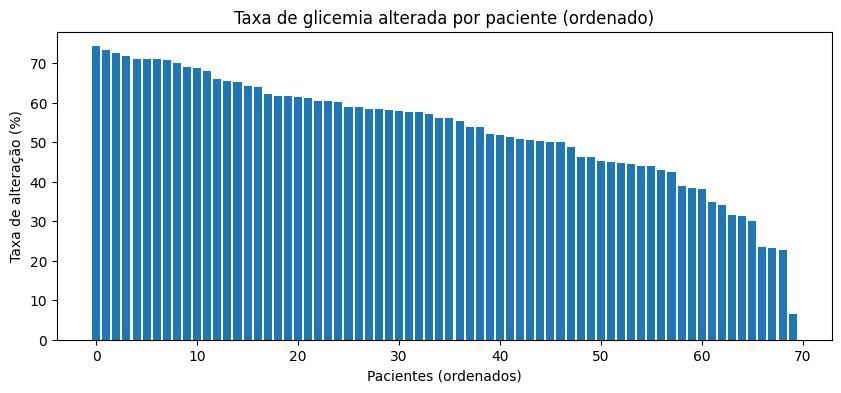

Taxa mínima entre pacientes: 6.5 %
Taxa máxima entre pacientes: 74.2 %
Desvio padrão das taxas entre pacientes: 14.2 p.p.


In [ ]:
taxa_paciente = gl.groupby('PatientID')['Glicemia_Alterada'].agg(['mean','count'])
taxa_paciente = taxa_paciente[taxa_paciente['count'] >= 30]
taxa_paciente = taxa_paciente.sort_values('mean', ascending=False)

plt.figure(figsize=(10,4))
plt.bar(range(len(taxa_paciente)), taxa_paciente['mean']*100)
plt.title('Taxa de glicemia alterada por paciente (ordenado)')
plt.xlabel('Pacientes (ordenados)')
plt.ylabel('Taxa de alteração (%)')
plt.show()

print('Taxa mínima entre pacientes:', round(taxa_paciente['mean'].min()*100,1), '%')
print('Taxa máxima entre pacientes:', round(taxa_paciente['mean'].max()*100,1), '%')
print('Desvio padrão das taxas entre pacientes:', round(taxa_paciente['mean'].std()*100,1), 'p.p.')

Esse foi um dos insights mais fortes da análise: a taxa de glicemia alterada varia enormemente entre pacientes (de ~6% a ~74%). Isso sugere que o paciente (`PatientID`) carrega muita informação sobre o risco, mas como é um identificador com 70 categorias e não temos garantia de que o modelo veria os mesmos pacientes no futuro, decidimos não usá-lo diretamente como feature.

# V. Pré-Processamento de Dados

### Checagem final de nulos

In [ ]:
gl.isnull().sum()

,0
Date,0
Time,0
Code,0
Value,0
PatientID,0
Evento,0
DataHora,5
Value_numerico,7
Glicemia_mgdl,0
Glicemia_Alterada,0


In [ ]:
gl = pd.get_dummies(gl, columns=['Momento_Medicao'], drop_first=True, dtype=int)
gl = pd.get_dummies(gl, columns=['Periodo_Dia'], dtype=int)
gl = pd.get_dummies(gl, columns=['DiaSemana'], drop_first=True, dtype=int)

gl = gl.sort_values(['PatientID', 'DataHora'])
gl['Glicemia_anterior'] = gl.groupby('PatientID')['Glicemia_mgdl'].shift(1)
gl['Glicemia_anterior'] = gl['Glicemia_anterior'].fillna(gl['Glicemia_mgdl'].mean())

### Definindo X (features) e y (target)

In [ ]:
colunas_features = [
    'Insulina_Dose_Dia',
    'Refeicao_Atipica',
    'Exercicio_Atipico',
    'Glicemia_anterior',
] + [c for c in gl.columns if c.startswith(('Momento_Medicao_', 'Periodo_Dia_', 'DiaSemana_'))]

X = gl[colunas_features]
y = gl['Glicemia_Alterada']

print(X.shape, y.shape)
X.head()

(13529, 21) (13529,)


,Insulina_Dose_Dia,Refeicao_Atipica,Exercicio_Atipico,Glicemia_anterior,Momento_Medicao_Pré-almoço,Momento_Medicao_Pré-café,Momento_Medicao_Pré-jantar,Momento_Medicao_Pré-lanche,Momento_Medicao_Pós-almoço,Momento_Medicao_Pós-café,Momento_Medicao_Pós-jantar,Periodo_Dia_Madrugada,Periodo_Dia_Manhã,Periodo_Dia_Noite,Periodo_Dia_Tarde,DiaSemana_Monday,DiaSemana_Saturday,DiaSemana_Sunday,DiaSemana_Thursday,DiaSemana_Tuesday,DiaSemana_Wednesday
0,29.0,0,0,160.362185,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,29.0,0,0,100.000000,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0
2,29.0,0,0,119.000000,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
3,32.0,0,0,123.000000,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
4,32.0,0,0,216.000000,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0


### Dividir em treino e teste (80% treino / 20% teste, estratificado pelo target)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10823, 21)
(2706, 21)
(10823,)
(2706,)


### Padronizar a variável contínua (`Insulina_Dose_Dia`)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
colunas_numericas = ['Insulina_Dose_Dia']

X_train.loc[:, colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test.loc[:, colunas_numericas] = scaler.transform(X_test[colunas_numericas])

X_train.head()

,Insulina_Dose_Dia,Refeicao_Atipica,Exercicio_Atipico,Glicemia_anterior,Momento_Medicao_Pré-almoço,Momento_Medicao_Pré-café,Momento_Medicao_Pré-jantar,Momento_Medicao_Pré-lanche,Momento_Medicao_Pós-almoço,Momento_Medicao_Pós-café,Momento_Medicao_Pós-jantar,Periodo_Dia_Madrugada,Periodo_Dia_Manhã,Periodo_Dia_Noite,Periodo_Dia_Tarde,DiaSemana_Monday,DiaSemana_Saturday,DiaSemana_Sunday,DiaSemana_Thursday,DiaSemana_Tuesday,DiaSemana_Wednesday
2214,-0.178632,0,0,48.0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
10404,-0.224633,0,0,98.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
4137,-0.178632,0,0,77.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
13389,-1.650664,0,0,326.0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
10770,-0.408637,0,0,246.0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29153 entries, 0 to 29329
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            29136 non-null  object        
 1   Time            29153 non-null  object        
 2   Code            29153 non-null  int64         
 3   Value           29153 non-null  object        
 4   PatientID       29153 non-null  object        
 5   Evento          29153 non-null  object        
 6   DataHora        29124 non-null  datetime64[ns]
 7   Value_numerico  29134 non-null  float64       
 8   Hora            29124 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 2.2+ MB


# Perguntas da Tarefa

### 1. Em quais etapas da análise exploratória você encontrou insights relevantes?

Na decodificação da coluna `Code`, ao perceber que havia códigos não documentados e datas/horários impossíveis, mesmo sem nenhum `NaN` explícito. Na coluna de glicemia, ao ver que valores `Hi`/`Lo` (texto) representavam justamente as leituras mais extremas, e não podiam ser simplesmente descartados. E, principalmente, na análise bivariada: a taxa de glicemia alterada varia muito conforme o momento da medição (pré vs pós-refeição), o período do dia (madrugada mais alterada) e entre pacientes (de ~6% a ~74%), enquanto o dia da semana quase não influencia.

### 2. A target para o seu problema está desbalanceada?

Não. O target `Glicemia_Alterada` ficou em aproximadamente **52% normal e 48% alterada**, relativamente equilibrado. Dentro do grupo "alterado", a maioria é hiperglicemia (36%) e uma minoria é hipoglicemia (12%).

### 3. Quais etapas de pré-processamento vocês realizaram? Por que escolheram essas ao invés de outras ensinadas?

Removemos códigos de evento não documentados e registros com data/hora inválida (poucas linhas, sem forma segura de corrigir). Tratamos os valores de glicemia em texto (`Hi`/`Lo`) mapeando para valores extremos plausíveis em vez de descartar, pois eram justamente os casos mais informativos (hipo/hiperglicemia grave). Aplicamos One-Hot Encoding em `Momento_Medicao` e `Periodo_Dia` (poucas categorias, sem ordem natural) e `StandardScaler` só na variável contínua (`Insulina_Dose_Dia`).

### 4. Quais variáveis foram criadas para o seu problema? Como vocês acham que ela irá contribuir para a predição?

Criamos: (1) `Momento_Medicao`, se a leitura foi antes ou depois de uma refeição — a variável com maior poder discriminativo na análise (pós-almoço 74% de alteração vs pré-almoço 44%). (2) `Periodo_Dia` (Madrugada/Manhã/Tarde/Noite), com diferença relevante (madrugada ~59% vs tarde ~45%) e mais fácil de generalizar do que o horário exato. (3) `Insulina_Dose_Dia`, soma das doses de insulina do paciente no dia, associada a mais dias com glicemia alterada (33.6 vs 38.4 unidades). (4) `Refeicao_Atipica` e `Exercicio_Atipico`, indicando refeição/exercício fora do padrão no dia — a primeira com impacto forte (46% -> 63%), a segunda mais moderado (47% -> 55%).

# Aula 2 - Regressão Logística

### Nesta etapa utilizaremos o dataset preparado na Aula 1 para treinar um modelo de classificação utilizando Regressão Logística.

#### I. Importação do modelo

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
colunas_numericas = ['Insulina_Dose_Dia', 'Glicemia_anterior']

X_train.loc[:, colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test.loc[:, colunas_numericas] = scaler.transform(X_test[colunas_numericas])

X_train.head()

,Insulina_Dose_Dia,Refeicao_Atipica,Exercicio_Atipico,Glicemia_anterior,Momento_Medicao_Pré-almoço,Momento_Medicao_Pré-café,Momento_Medicao_Pré-jantar,Momento_Medicao_Pré-lanche,Momento_Medicao_Pós-almoço,Momento_Medicao_Pós-café,Momento_Medicao_Pós-jantar,Periodo_Dia_Madrugada,Periodo_Dia_Manhã,Periodo_Dia_Noite,Periodo_Dia_Tarde,DiaSemana_Monday,DiaSemana_Saturday,DiaSemana_Sunday,DiaSemana_Thursday,DiaSemana_Tuesday,DiaSemana_Wednesday
2214,-0.178632,0,0,-1.401915,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
10404,-0.224633,0,0,-0.776897,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
4137,-0.178632,0,0,-1.039405,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
13389,-1.650664,0,0,2.073185,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
10770,-0.408637,0,0,1.073156,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [ ]:
# Esse primeiro código está mais equilibrado entre as classes no resultado final
model = LogisticRegression(random_state=42,max_iter=1000)

# o segundo melhora a classe 0, porém piora bastante a detecção da classe 1.
#model = LogisticRegression(random_state=42, class_weight="balanced")

#### II. Treinamento

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

#### III. Avaliação

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6189948263118995

In [ ]:
y_prob = model.predict_proba(X_test)

y_prob[:10]

array([[0.64358886, 0.35641114],
       [0.61499193, 0.38500807],
       [0.47439035, 0.52560965],
       [0.55610137, 0.44389863],
       [0.66570867, 0.33429133],
       [0.45733827, 0.54266173],
       [0.53269819, 0.46730181],
       [0.31757906, 0.68242094],
       [0.45815084, 0.54184916],
       [0.59032289, 0.40967711]])

In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.73      0.67      1415
           1       0.63      0.49      0.55      1291

    accuracy                           0.62      2706
   macro avg       0.62      0.61      0.61      2706
weighted avg       0.62      0.62      0.61      2706



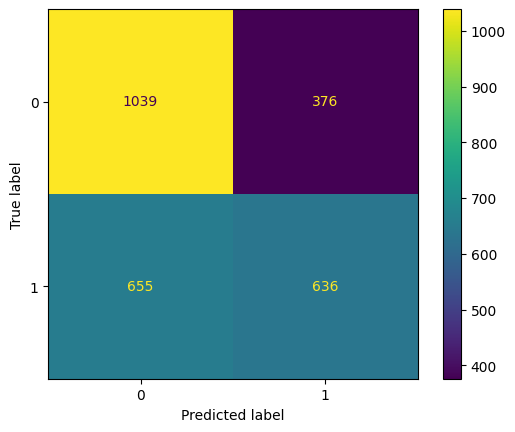

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()